In [1]:
import pandas as pd

In [2]:
personality = pd.read_csv('dataset/personality_dataset.csv')
personality.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


In [3]:
personality.isnull().sum()

Time_spent_Alone             63
Stage_fear                   73
Social_event_attendance      62
Going_outside                66
Drained_after_socializing    52
Friends_circle_size          77
Post_frequency               65
Personality                   0
dtype: int64

In [4]:
len(personality)

2900

In [5]:
#Handaling missing values
personality.dtypes

Time_spent_Alone             float64
Stage_fear                    object
Social_event_attendance      float64
Going_outside                float64
Drained_after_socializing     object
Friends_circle_size          float64
Post_frequency               float64
Personality                   object
dtype: object

In [6]:
personality.value_counts('Personality')

Personality
Extrovert    1491
Introvert    1409
Name: count, dtype: int64

In [13]:
personality.value_counts('Stage_fear')

Stage_fear
No     1417
Yes    1410
Name: count, dtype: int64

In [14]:
personality.value_counts('Drained_after_socializing')

Drained_after_socializing
No     1441
Yes    1407
Name: count, dtype: int64

In [7]:
personality.describe()

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,2837.000000,2838.000000,2834.000000,2823.000000,2835.000000
mean,4.505816,3.963354,3.000000,6.268863,3.564727
std,3.479192,2.903827,2.247327,4.289693,2.926582
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,1.000000,3.000000,1.000000
50%,4.000000,3.000000,3.000000,5.000000,3.000000
75%,8.000000,6.000000,5.000000,10.000000,6.000000
max,11.000000,10.000000,7.000000,15.000000,10.000000


In [6]:
num_cols = ['Time_spent_Alone','Social_event_attendance','Going_outside','Friends_circle_size','Post_frequency']
cat_cols = ['Stage_fear','Drained_after_socializing']

In [14]:
from sklearn.preprocessing import LabelEncoder
personality[personality.select_dtypes('object').columns] = personality.select_dtypes('object').apply(LabelEncoder().fit_transform)

In [15]:
personality.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,0,4.0,6.0,0,13.0,5.0,0
1,9.0,1,0.0,0.0,1,0.0,3.0,1
2,9.0,1,1.0,2.0,1,5.0,2.0,1
3,0.0,0,6.0,7.0,0,14.0,8.0,0
4,3.0,0,9.0,4.0,0,8.0,5.0,0


In [16]:
#correlation matrix
correlation_matrix = personality.corr(numeric_only= True)
correlation_matrix


,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
Time_spent_Alone,1.000000,0.754872,-0.733011,-0.750760,0.803352,-0.717185,-0.732649,0.720312
Stage_fear,0.754872,1.000000,-0.754771,-0.777804,0.821857,-0.732254,-0.750167,0.763340
Social_event_attendance,-0.733011,-0.754771,1.000000,0.747756,-0.805825,0.734795,0.744615,-0.729417
Going_outside,-0.750760,-0.777804,0.747756,1.000000,-0.821719,0.736390,0.770819,-0.747794
Drained_after_socializing,0.803352,0.821857,-0.805825,-0.821719,1.000000,-0.777299,-0.795838,0.813410
Friends_circle_size,-0.717185,-0.732254,0.734795,0.736390,-0.777299,1.000000,0.707888,-0.696507
Post_frequency,-0.732649,-0.750167,0.744615,0.770819,-0.795838,0.707888,1.000000,-0.729287
Personality,0.720312,0.763340,-0.729417,-0.747794,0.813410,-0.696507,-0.729287,1.000000


In [18]:
target_corr = correlation_matrix['Personality'].sort_values(ascending=False)
target_corr

Personality                  1.000000
Drained_after_socializing    0.813410
Stage_fear                   0.763340
Time_spent_Alone             0.720312
Friends_circle_size         -0.696507
Post_frequency              -0.729287
Social_event_attendance     -0.729417
Going_outside               -0.747794
Name: Personality, dtype: float64

In [19]:
corr_features = target_corr.abs().sort_values(ascending=False)
corr_features = corr_features.drop('Personality')
corr_features

Drained_after_socializing    0.813410
Stage_fear                   0.763340
Going_outside                0.747794
Social_event_attendance      0.729417
Post_frequency               0.729287
Time_spent_Alone             0.720312
Friends_circle_size          0.696507
Name: Personality, dtype: float64

In [20]:
top3_features = corr_features.abs().sort_values(ascending=False).head(3).index.to_list()
top3_features

['Drained_after_socializing', 'Stage_fear', 'Going_outside']

In [21]:
corr_matrix = personality.corr()

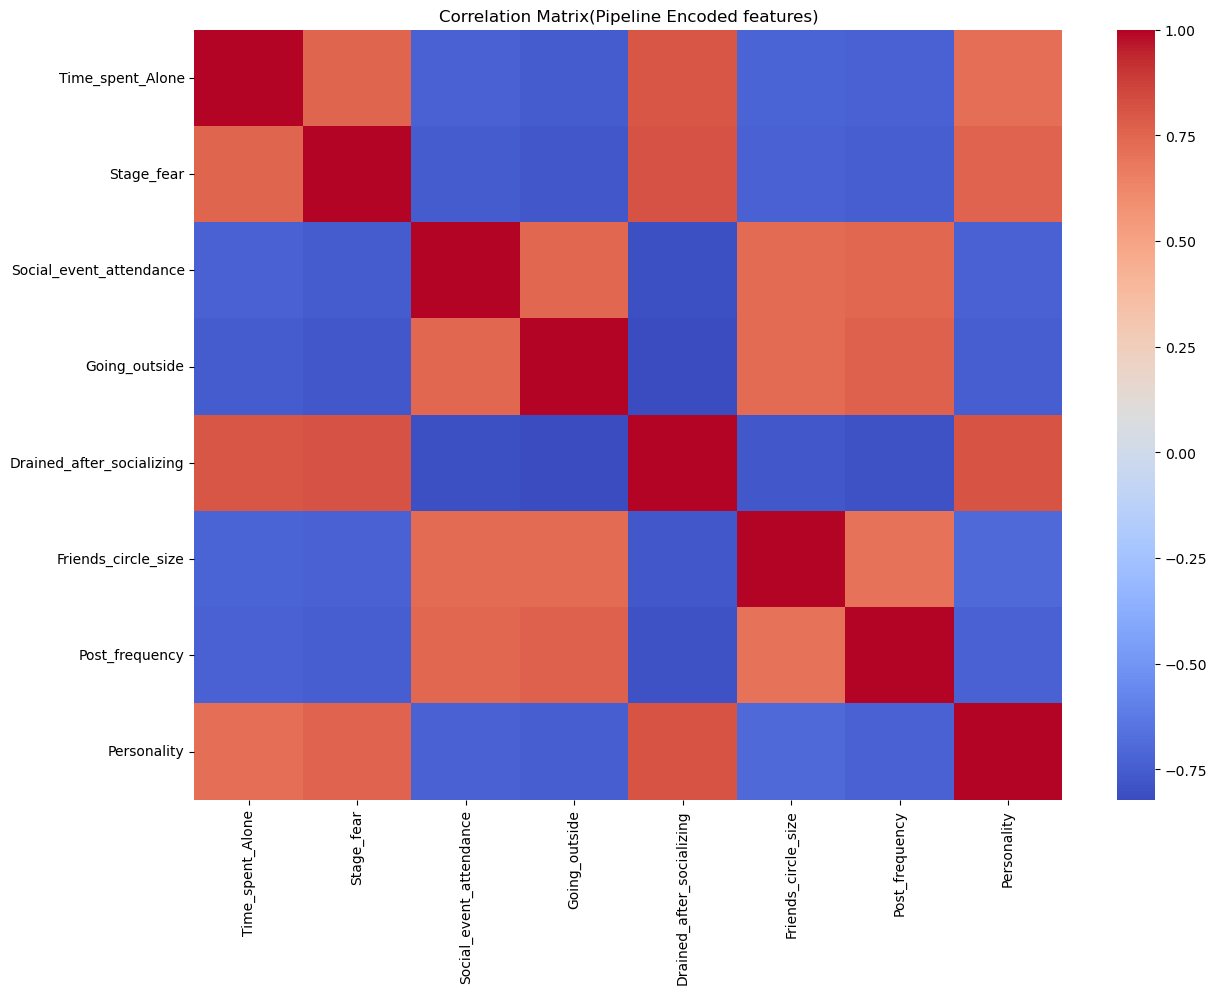

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap = 'coolwarm')
plt.title("Correlation Matrix(Pipeline Encoded features)")
plt.show()
